In [1]:
import qiskit

In [2]:
qiskit.__version__

'2.0.2'

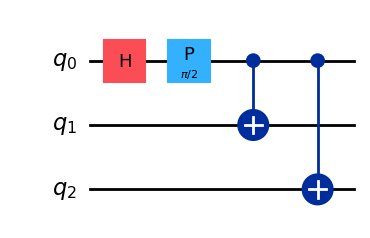

In [2]:
import numpy as np
from qiskit import QuantumCircuit

# 1. A quantum circuit for preparing the quantum state |000> + i |111> / √2
qc = QuantumCircuit(3)
qc.h(0)             # generate superposition
qc.p(np.pi / 2, 0)  # add quantum phase
qc.cx(0, 1)         # 0th-qubit-Controlled-NOT gate on 1st qubit
qc.cx(0, 2)         # 0th-qubit-Controlled-NOT gate on 2nd qubit
qc.draw('mpl')
#qc.draw('latex')

In [3]:
# 2. Add the classical output in the form of measurement of all qubits
qc_measured = qc.measure_all(inplace=False)

# 3. Execute using the Sampler primitive
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()
job = sampler.run([qc_measured], shots=1000)
result = job.result()
print(f" > Counts: {result[0].data['meas'].get_counts()}")

 > Counts: {'000': 494, '111': 506}


In [4]:
# 2. Define the observable to be measured 
from qiskit.quantum_info import SparsePauliOp
operator = SparsePauliOp.from_list([("XXY", 1), ("XYX", 1), ("YXX", 1), ("YYY", -1)])

# 3. Execute using the Estimator primitive
from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()
job = estimator.run([(qc, operator)], precision=1e-3)
result = job.result()
print(f" > Expectation values: {result[0].data.evs}")

 > Expectation values: 3.9992837007683497


In [5]:
from qiskit import transpile
qc_transpiled = transpile(qc, basis_gates=["cz", "sx", "rz"], coupling_map=[[0, 1], [1, 2]], optimization_level=3)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel = "ibm_quantum", token = "")

backend = service.backend(name = "ibm_sherbrooke")

C:\Users\rem.gabryldellarosa\AppData\Local\Temp\ipykernel_5308\214172240.py:2: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(channel = "ibm_quantum", token = "")


In [7]:
backend.num_qubits

127